In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Model
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os
import cv2
import matplotlib.pyplot as plt

# Paths
image_folder = "Water Bodies Dataset/Images/"
mask_folder = "Water Bodies Dataset/Masks/"
img_size = (128, 128)  # Resize all images to this shape for the model

def load_data(folder, size):
    data = []
    for filename in sorted(os.listdir(folder)):
        if filename.endswith(".jpg"):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            img = cv2.resize(img, size)
            img = img / 255.0  # Normalize
            data.append(img)
    return np.array(data)

# Load images and masks
images = load_data(image_folder, img_size)
masks = load_data(mask_folder, img_size)

# Ensure masks are binary
masks = (masks[..., 0] > 0.5).astype(np.float32)
masks = np.expand_dims(masks, axis=-1)

# Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

In [3]:
# Build improved U-Net model
def unet_model(input_shape, dropout_rate=0.1):
    # Input
    inputs = Input(shape=input_shape)
    
    # Encoder (Downsampling path)
    # Block 1
    c1 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(dropout_rate)(p1)
    
    # Block 2
    c2 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(dropout_rate)(p2)
    
    # Block 3
    c3 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(dropout_rate)(p3)
    
    # Bottleneck
    c4 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    c4 = BatchNormalization()(c4)
    p4 = Dropout(dropout_rate*2)(c4)
    
    # Decoder (Upsampling path)
    # Block 5
    u5 = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(p4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u5)
    c5 = BatchNormalization()(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(dropout_rate)(c5)
    
    # Block 6
    u6 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    c6 = BatchNormalization()(c6)
    c6 = Dropout(dropout_rate)(c6)
    
    # Block 7
    u7 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = BatchNormalization()(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    c7 = BatchNormalization()(c7)
    c7 = Dropout(dropout_rate)(c7)
    
    # Output layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c7)
    
    # Model compilation
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Function to train model with improved parameters
def train_water_body_detection_model(X_train, y_train, X_val, y_val, img_size, batch_size=8, epochs=50):
    # Create and compile model
    model = unet_model(input_shape=(img_size[0], img_size[1], 3))
    
    # Use a lower learning rate for better convergence
    optimizer = Adam(learning_rate=1e-4)
    
    # Compile with appropriate loss function for segmentation
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), 
                 tf.keras.metrics.MeanIoU(num_classes=2)]
    )
    
    # Define callbacks for better training
    callbacks = [
        # Save best model during training
        ModelCheckpoint(
            "unet_water_body_best_model.h5", 
            save_best_only=True,
            monitor='val_mean_io_u',
            mode='max'
        ),
        # Stop training if no improvement
        EarlyStopping(
            patience=10,
            monitor='val_mean_io_u',
            mode='max',
            restore_best_weights=True
        ),
        # Reduce learning rate when plateau is reached
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6
        )
    ]
    
    # Data augmentation for better generalization
    data_gen_args = dict(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.2,
        fill_mode='nearest'
    )
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )
    
    # Save final model
    model.save("unet_water_body_detection_final.h5")
    
    return model, history

# Function to plot training history with additional metrics
def plot_training_history(history):
    # Create a figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot accuracy
    axs[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axs[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0, 0].set_title('Model Accuracy')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].legend(loc='lower right')
    
    # Plot loss
    axs[0, 1].plot(history.history['loss'], label='Training Loss')
    axs[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axs[0, 1].set_title('Model Loss')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend(loc='upper right')
    
    # Plot IoU
    axs[1, 0].plot(history.history['mean_io_u'], label='Training IoU')
    axs[1, 0].plot(history.history['val_mean_io_u'], label='Validation IoU')
    axs[1, 0].set_title('Mean IoU')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('IoU')
    axs[1, 0].legend(loc='lower right')
    
    # Plot Precision-Recall
    axs[1, 1].plot(history.history['precision'], label='Training Precision')
    axs[1, 1].plot(history.history['val_precision'], label='Validation Precision')
    axs[1, 1].plot(history.history['recall'], label='Training Recall')
    axs[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axs[1, 1].set_title('Precision and Recall')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Score')
    axs[1, 1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

# Function to visualize prediction results
def visualize_predictions(model, X_test, y_test, num_samples=5):
    # Get predictions
    y_pred = model.predict(X_test[:num_samples])
    
    # Create figure
    fig, axs = plt.subplots(num_samples, 3, figsize=(15, num_samples*5))
    
    for i in range(num_samples):
        # Display original image
        axs[i, 0].imshow(X_test[i])
        axs[i, 0].set_title('Original Image')
        axs[i, 0].axis('off')
        
        # Display ground truth mask
        axs[i, 1].imshow(y_test[i].squeeze(), cmap='gray')
        axs[i, 1].set_title('Ground Truth')
        axs[i, 1].axis('off')
        
        # Display predicted mask
        axs[i, 2].imshow(y_pred[i].squeeze(), cmap='gray')
        axs[i, 2].set_title('Prediction')
        axs[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('prediction_results.png')
    plt.show()

In [14]:
model, history = train_water_body_detection_model(X_train, y_train, X_val, y_val, img_size)
    
    # Plot training history
plot_training_history(history)

Epoch 1/50


C:\Users\asifu\anaconda3\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_14']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7498 - loss: 0.5513 - mean_io_u: 0.3489 - precision: 0.5817 - recall: 0.7230

C:\Users\asifu\anaconda3\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_14']
Received: inputs=Tensor(shape=(8, 128, 128, 3))
  warnings.warn(msg)


272/272 ━━━━━━━━━━━━━━━━━━━━ 2290s 8s/step - accuracy: 0.7500 - loss: 0.5510 - mean_io_u: 0.3490 - precision: 0.5820 - recall: 0.7230 - val_accuracy: 0.8033 - val_loss: 0.5745 - val_mean_io_u: 0.4000 - val_precision: 0.6373 - val_recall: 0.7835 - learning_rate: 1.0000e-04
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2189s 8s/step - accuracy: 0.8543 - loss: 0.3705 - mean_io_u: 0.3772 - precision: 0.7669 - recall: 0.7167 - val_accuracy: 0.8587 - val_loss: 0.3438 - val_mean_io_u: 0.3840 - val_precision: 0.7448 - val_recall: 0.7975 - learning_rate: 1.0000e-04
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8686 - loss: 0.3332 - mean_io_u: 0.3825 - precision: 0.7924 - recall: 0.7460

272/272 ━━━━━━━━━━━━━━━━━━━━ 2197s 8s/step - accuracy: 0.8686 - loss: 0.3332 - mean_io_u: 0.3825 - precision: 0.7925 - recall: 0.7460 - val_accuracy: 0.8819 - val_loss: 0.2996 - val_mean_io_u: 0.4177 - val_precision: 0.8398 - val_recall: 0.7441 - learning_rate: 1.0000e-04
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2170s 8s/step - accuracy: 0.8729 - loss: 0.3217 - mean_io_u: 0.3851 - precision: 0.8038 - recall: 0.7526 - val_accuracy: 0.8924 - val_loss: 0.2649 - val_mean_io_u: 0.4082 - val_precision: 0.8245 - val_recall: 0.8102 - learning_rate: 1.0000e-04
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2135s 8s/step - accuracy: 0.8821 - loss: 0.2998 - mean_io_u: 0.3884 - precision: 0.8175 - recall: 0.7753 - val_accuracy: 0.8953 - val_loss: 0.2589 - val_mean_io_u: 0.3891 - val_precision: 0.8450 - val_recall: 0.7929 - learning_rate: 1.0000e-04
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2130s 8s/step - accuracy: 0.8872 - loss: 0.2894 - mean_io_u: 0.3896 - precision: 0.8344 - recall: 0.7699 - val_accuracy

272/272 ━━━━━━━━━━━━━━━━━━━━ 2184s 8s/step - accuracy: 0.8946 - loss: 0.2658 - mean_io_u: 0.3906 - precision: 0.8467 - recall: 0.7872 - val_accuracy: 0.8961 - val_loss: 0.2585 - val_mean_io_u: 0.4227 - val_precision: 0.8094 - val_recall: 0.8503 - learning_rate: 1.0000e-04
Epoch 8/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2203s 8s/step - accuracy: 0.8987 - loss: 0.2591 - mean_io_u: 0.3902 - precision: 0.8514 - recall: 0.7982 - val_accuracy: 0.9108 - val_loss: 0.2282 - val_mean_io_u: 0.4058 - val_precision: 0.8988 - val_recall: 0.7884 - learning_rate: 1.0000e-04
Epoch 9/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9037 - loss: 0.2485 - mean_io_u: 0.3923 - precision: 0.8681 - recall: 0.7979

272/272 ━━━━━━━━━━━━━━━━━━━━ 2130s 8s/step - accuracy: 0.9037 - loss: 0.2485 - mean_io_u: 0.3923 - precision: 0.8680 - recall: 0.7980 - val_accuracy: 0.9048 - val_loss: 0.2480 - val_mean_io_u: 0.4308 - val_precision: 0.8559 - val_recall: 0.8171 - learning_rate: 1.0000e-04
Epoch 10/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2151s 8s/step - accuracy: 0.9032 - loss: 0.2498 - mean_io_u: 0.3919 - precision: 0.8606 - recall: 0.8057 - val_accuracy: 0.9123 - val_loss: 0.2277 - val_mean_io_u: 0.4272 - val_precision: 0.8754 - val_recall: 0.8218 - learning_rate: 1.0000e-04
Epoch 11/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2117s 8s/step - accuracy: 0.9059 - loss: 0.2394 - mean_io_u: 0.3912 - precision: 0.8615 - recall: 0.8166 - val_accuracy: 0.9133 - val_loss: 0.2258 - val_mean_io_u: 0.4002 - val_precision: 0.8839 - val_recall: 0.8150 - learning_rate: 1.0000e-04
Epoch 12/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2116s 8s/step - accuracy: 0.9124 - loss: 0.2247 - mean_io_u: 0.3884 - precision: 0.8691 - recall: 0.8261 - val_accur

272/272 ━━━━━━━━━━━━━━━━━━━━ 2117s 8s/step - accuracy: 0.9161 - loss: 0.2160 - mean_io_u: 0.3877 - precision: 0.8816 - recall: 0.8298 - val_accuracy: 0.9200 - val_loss: 0.2129 - val_mean_io_u: 0.4458 - val_precision: 0.8968 - val_recall: 0.8255 - learning_rate: 1.0000e-04
Epoch 17/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2116s 8s/step - accuracy: 0.9228 - loss: 0.2048 - mean_io_u: 0.3883 - precision: 0.8908 - recall: 0.8405 - val_accuracy: 0.9171 - val_loss: 0.2219 - val_mean_io_u: 0.4121 - val_precision: 0.8639 - val_recall: 0.8556 - learning_rate: 1.0000e-04
Epoch 18/50
125/272 ━━━━━━━━━━━━━━━━━━━━ 34:52 14s/step - accuracy: 0.9243 - loss: 0.2022 - mean_io_u: 0.3913 - precision: 0.8889 - recall: 0.8467


KeyboardInterrupt



In [19]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Define custom metrics dictionary for loading the model
custom_objects = {
    'mean_io_u': tf.keras.metrics.MeanIoU(num_classes=2)
}

# Load the best model saved by ModelCheckpoint
model = load_model('unet_water_body_best_model.h5', custom_objects=custom_objects)

# Recompile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), 
             tf.keras.metrics.MeanIoU(num_classes=2)]
)

In [20]:
# Define callbacks for better training
callbacks = [
    # Save best model during training
    ModelCheckpoint(
        "unet_water_body_best_model.h5", 
        save_best_only=True,
        monitor='val_mean_io_u',
        mode='max'
    ),
    # Stop training if no improvement
    EarlyStopping(
        patience=10,
        monitor='val_mean_io_u',
        mode='max',
        restore_best_weights=True
    ),
    # Reduce learning rate when plateau is reached
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    )
]

In [21]:
# Resume training
new_history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    initial_epoch=17,  # Start from epoch 16
    epochs=50,         # Continue up to 50 total epochs
    batch_size=8,
    callbacks=callbacks
)

Epoch 18/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2173s 8s/step - accuracy: 0.9223 - loss: 0.2080 - mean_io_u_2: 0.3871 - precision_1: 0.8920 - recall_1: 0.8427 - val_accuracy: 0.9136 - val_loss: 0.2239 - val_mean_io_u_2: 0.3731 - val_precision_1: 0.8511 - val_recall_1: 0.8593 - learning_rate: 1.0000e-04
Epoch 19/50


C:\Users\asifu\anaconda3\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:209: UserWarning: Can save best model only with val_mean_io_u available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)
C:\Users\asifu\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_mean_io_u` which is not available. Available metrics are: accuracy,loss,mean_io_u_2,precision_1,recall_1,val_accuracy,val_loss,val_mean_io_u_2,val_precision_1,val_recall_1
  current = self.get_monitor_value(logs)


272/272 ━━━━━━━━━━━━━━━━━━━━ 2182s 8s/step - accuracy: 0.9230 - loss: 0.2035 - mean_io_u_2: 0.3859 - precision_1: 0.8905 - recall_1: 0.8457 - val_accuracy: 0.9206 - val_loss: 0.2165 - val_mean_io_u_2: 0.4761 - val_precision_1: 0.8882 - val_recall_1: 0.8383 - learning_rate: 1.0000e-04
Epoch 20/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2129s 8s/step - accuracy: 0.9210 - loss: 0.2106 - mean_io_u_2: 0.3865 - precision_1: 0.8881 - recall_1: 0.8395 - val_accuracy: 0.9133 - val_loss: 0.2257 - val_mean_io_u_2: 0.4391 - val_precision_1: 0.8910 - val_recall_1: 0.8066 - learning_rate: 1.0000e-04
Epoch 21/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2177s 8s/step - accuracy: 0.9242 - loss: 0.2013 - mean_io_u_2: 0.3877 - precision_1: 0.8975 - recall_1: 0.8405 - val_accuracy: 0.9138 - val_loss: 0.2283 - val_mean_io_u_2: 0.3680 - val_precision_1: 0.8677 - val_recall_1: 0.8373 - learning_rate: 1.0000e-04
Epoch 22/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2108s 8s/step - accuracy: 0.9273 - loss: 0.1896 - mean_io_u_2: 0.3863 - precisio

In [26]:
 #Function to plot training history with additional metrics
def plot_training_history(history):
    # Create a figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot accuracy
    axs[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axs[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0, 0].set_title('Model Accuracy')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].legend(loc='lower right')
    
    # Plot loss
    axs[0, 1].plot(history.history['loss'], label='Training Loss')
    axs[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axs[0, 1].set_title('Model Loss')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend(loc='upper right')
    
    # Plot IoU
    axs[1, 0].plot(history.history['mean_io_u_2'], label='Training IoU')
    axs[1, 0].plot(history.history['val_mean_io_u_2'], label='Validation IoU')
    axs[1, 0].set_title('Mean IoU')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('IoU')
    axs[1, 0].legend(loc='lower right')
    
    # Plot Precision-Recall
    axs[1, 1].plot(history.history['precision_1'], label='Training Precision')
    axs[1, 1].plot(history.history['val_precision_1'], label='Validation Precision')
    axs[1, 1].plot(history.history['recall_1'], label='Training Recall')
    axs[1, 1].plot(history.history['val_recall_1'], label='Validation Recall')
    axs[1, 1].set_title('Precision and Recall')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Score')
    axs[1, 1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

# Function to visualize prediction results
def visualize_predictions(model, X_test, y_test, num_samples=5):
    # Get predictions
    y_pred = model.predict(X_test[:num_samples])
    
    # Create figure
    fig, axs = plt.subplots(num_samples, 3, figsize=(15, num_samples*5))
    
    for i in range(num_samples):
        # Display original image
        axs[i, 0].imshow(X_test[i])
        axs[i, 0].set_title('Original Image')
        axs[i, 0].axis('off')
        
        # Display ground truth mask
        axs[i, 1].imshow(y_test[i].squeeze(), cmap='gray')
        axs[i, 1].set_title('Ground Truth')
        axs[i, 1].axis('off')
        
        # Display predicted mask
        axs[i, 2].imshow(y_pred[i].squeeze(), cmap='gray')
        axs[i, 2].set_title('Prediction')
        axs[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('prediction_results.png')
    plt.show()

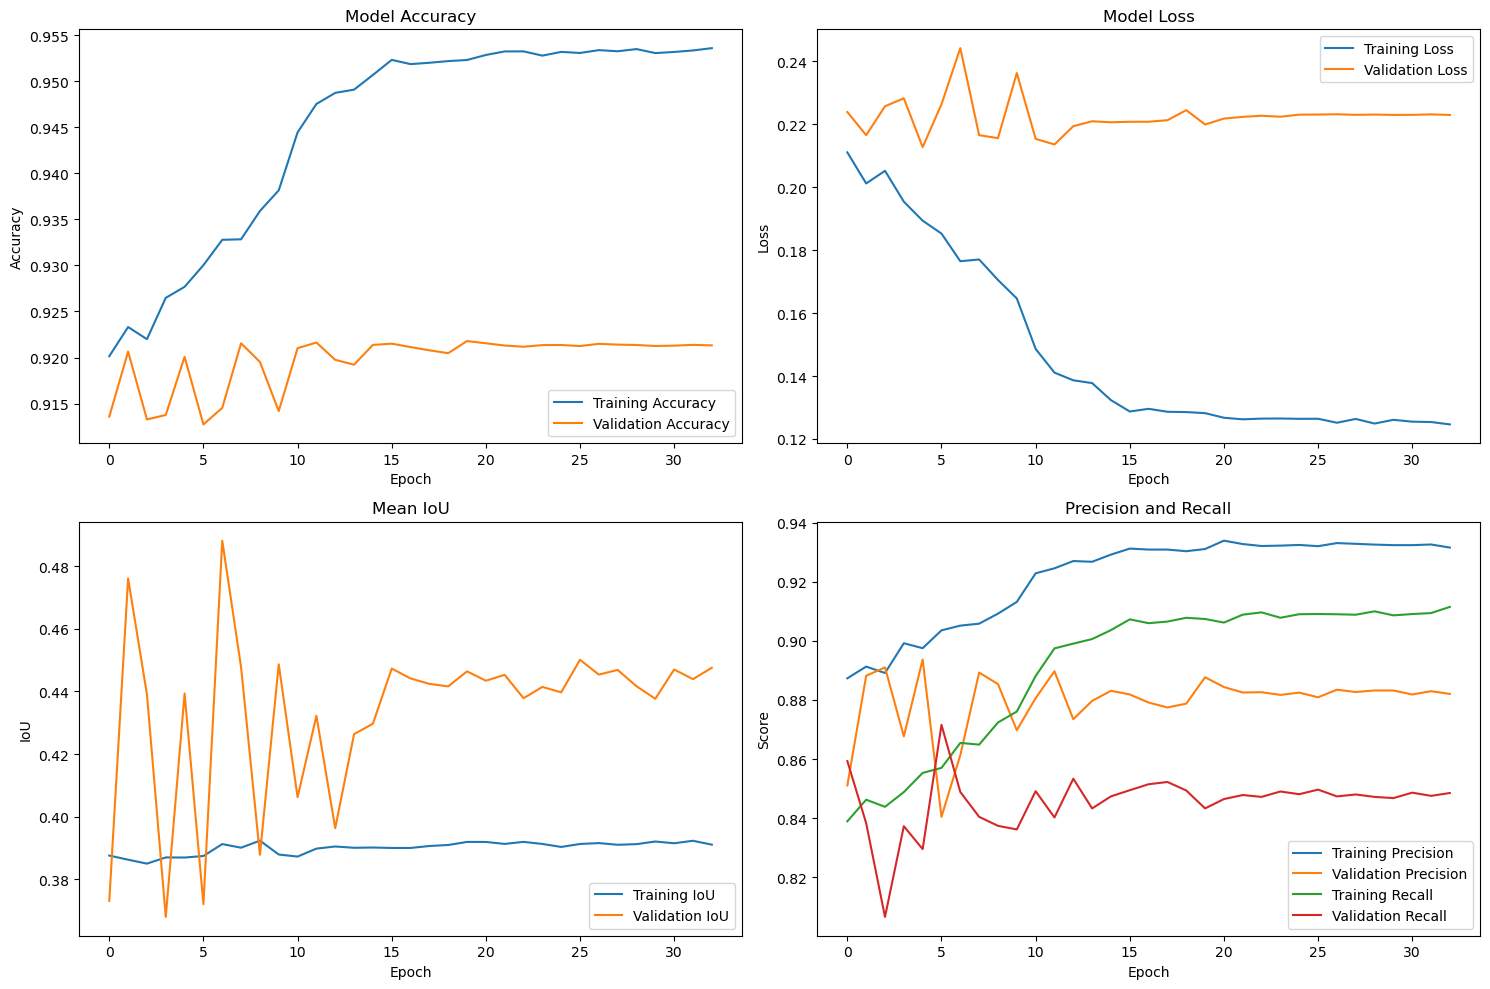

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


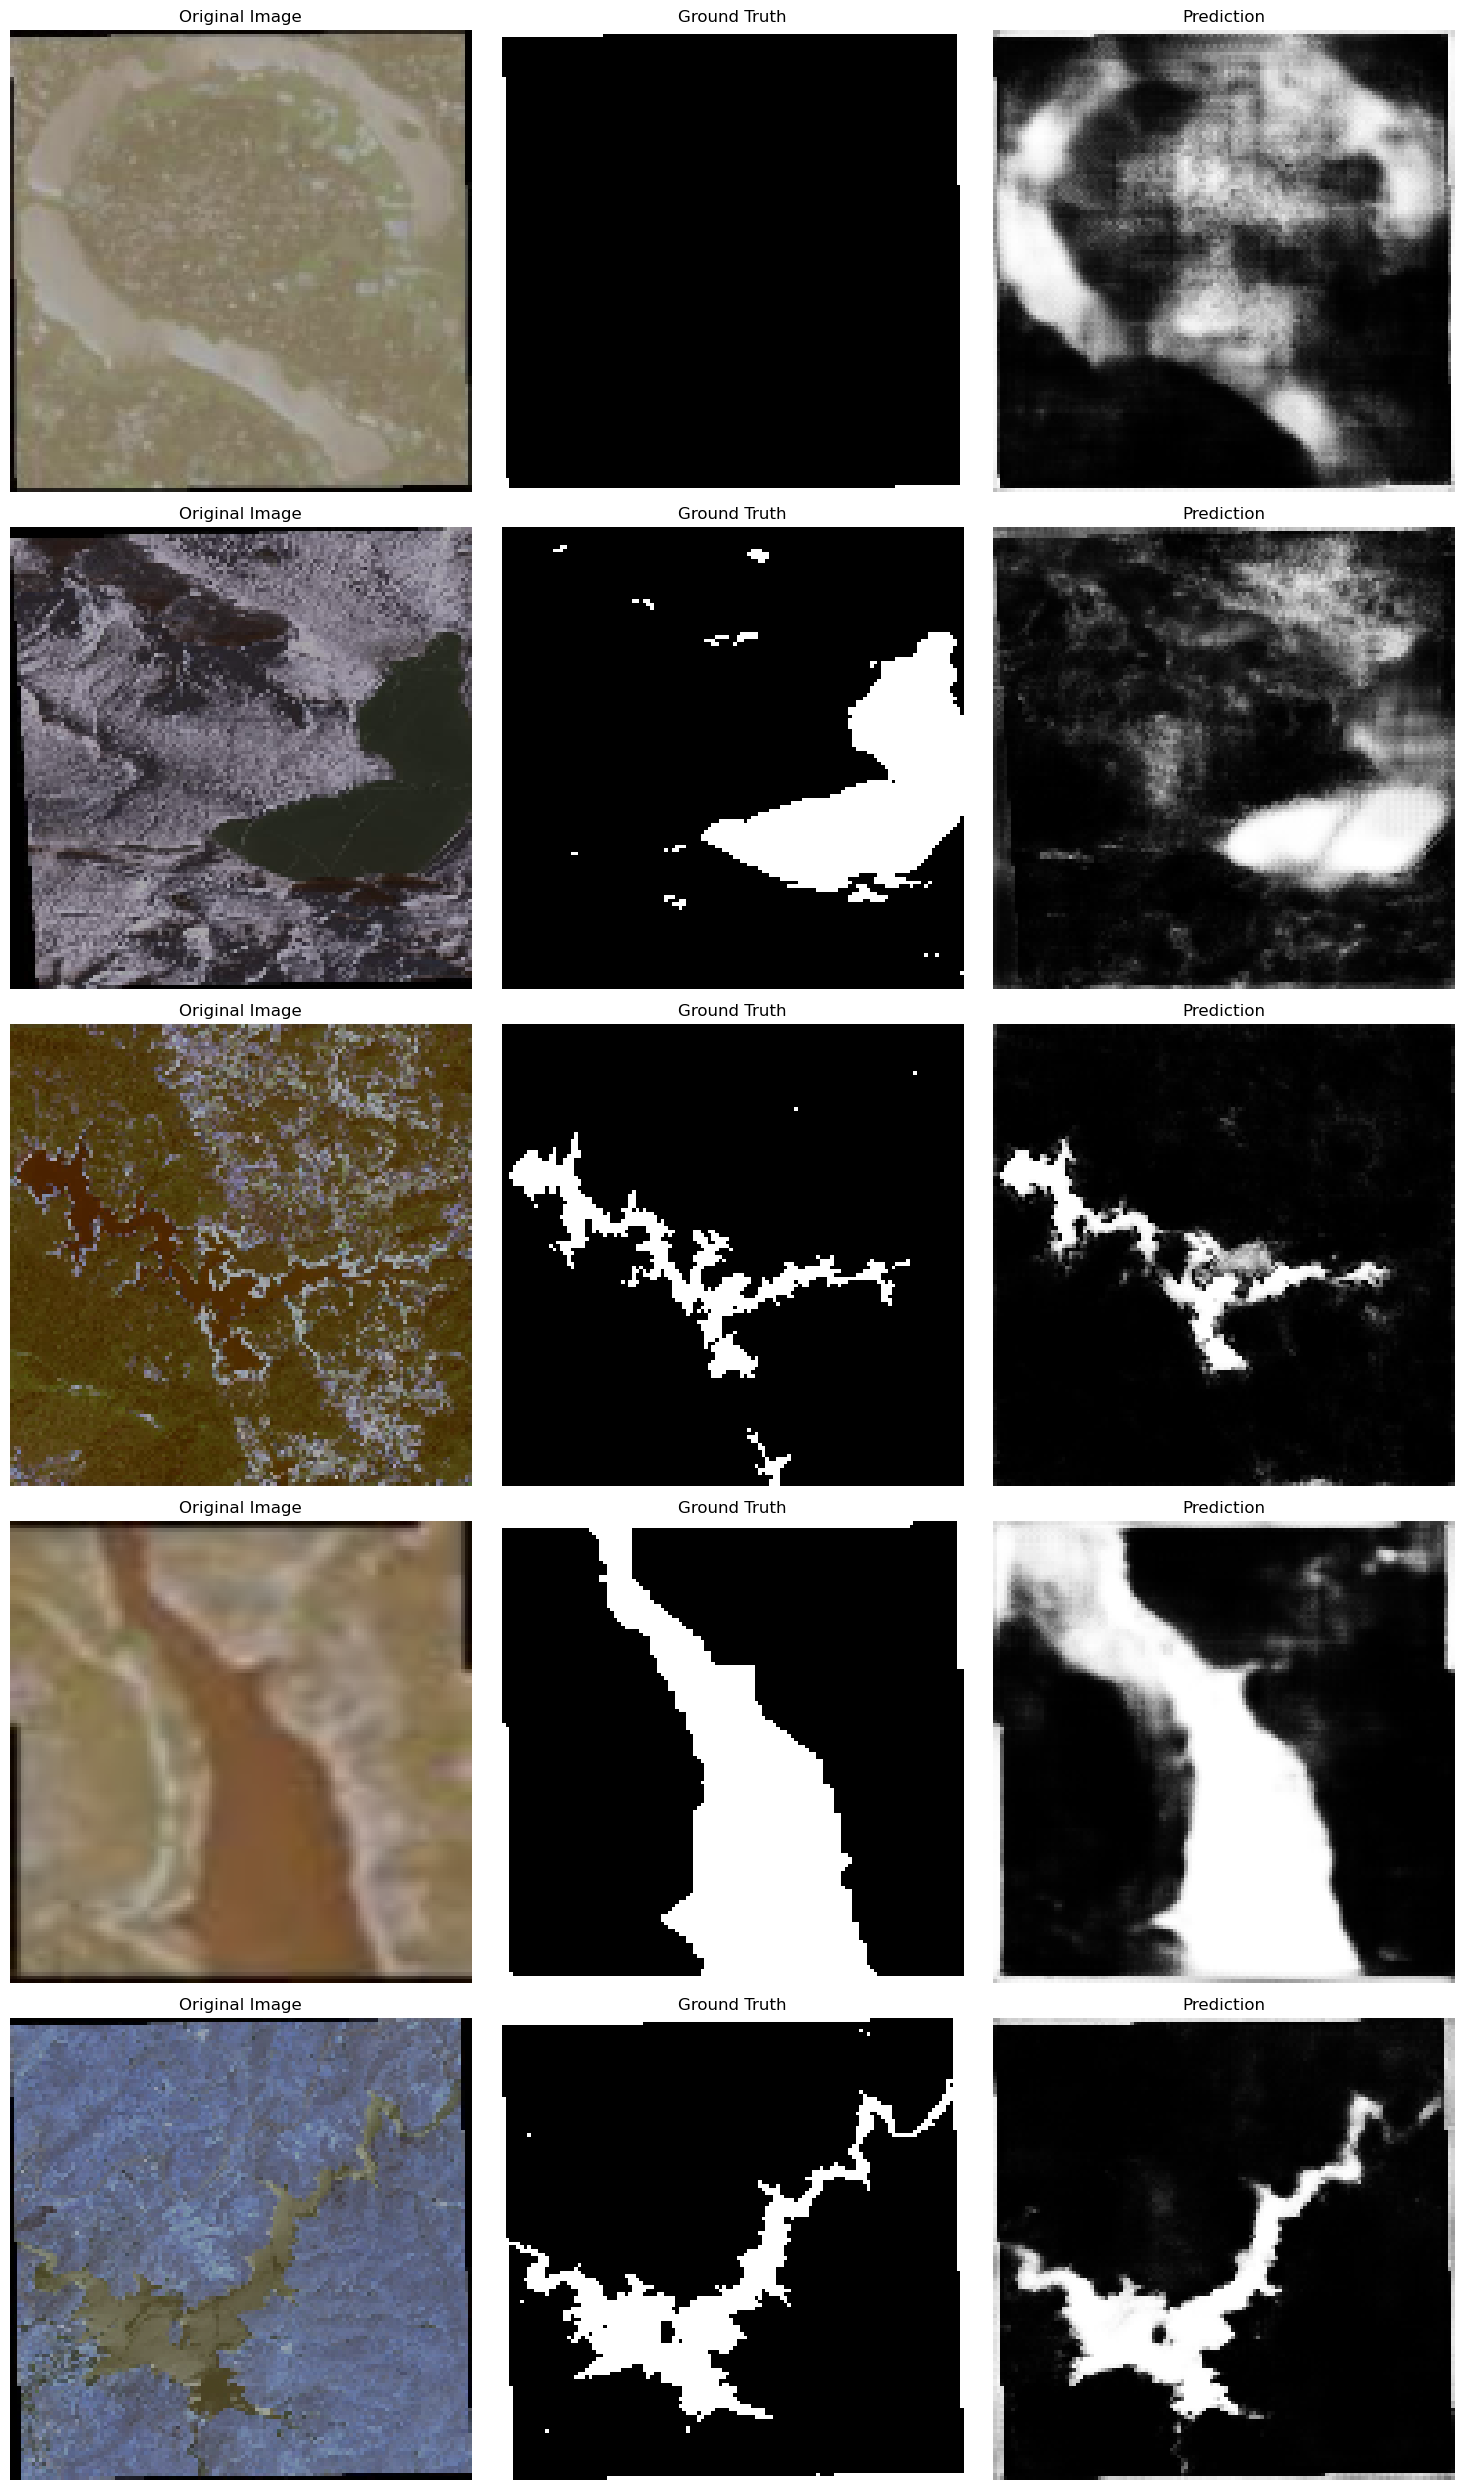

In [33]:
# Plot the training history (just for the resumed portion)
plot_training_history(new_history)

# Visualize some predictions if you have test data
visualize_predictions(model, X_val, y_val, num_samples=5)

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_10[0][0] 

 Total params: 8,568,771 (32.69 MB)

 Trainable params: 8,563,137 (32.67 MB)

 Non-trainable params: 5,632 (22.00 KB)

 Optimizer params: 2 (12.00 B)

### Testing ###

In [21]:
import random
import tensorflow as tf
# Load the saved model
model = tf.keras.models.load_model("unet_water_body_best_model.h5")

# Make predictions on validation images
predictions = model.predict(X_val)

# Threshold the predicted masks
predicted_masks = (predictions > 0.5).astype(np.uint8)



17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step


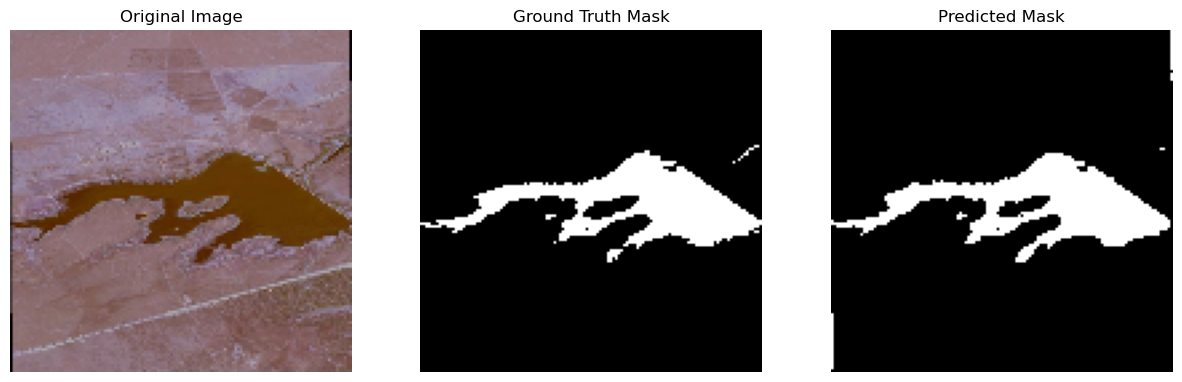

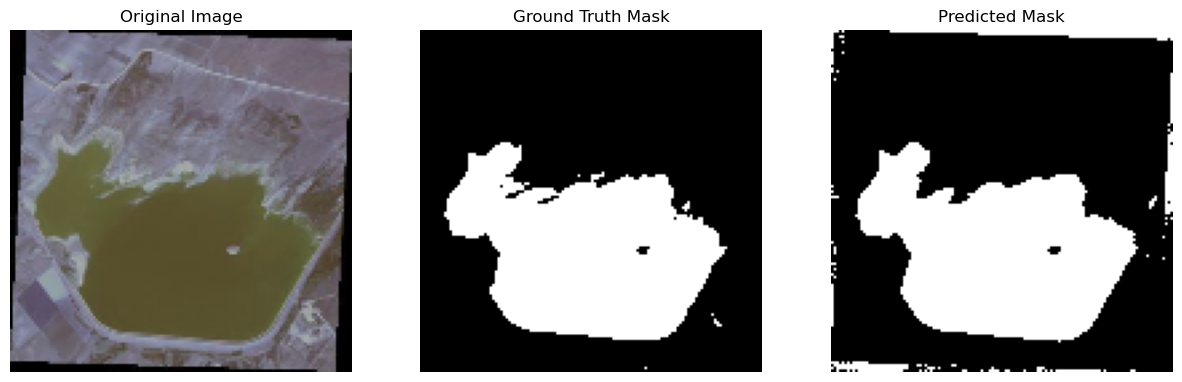

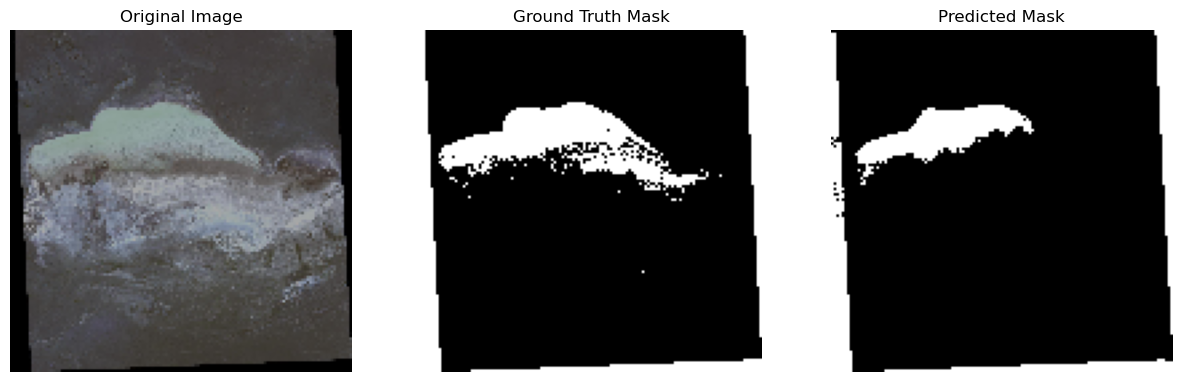

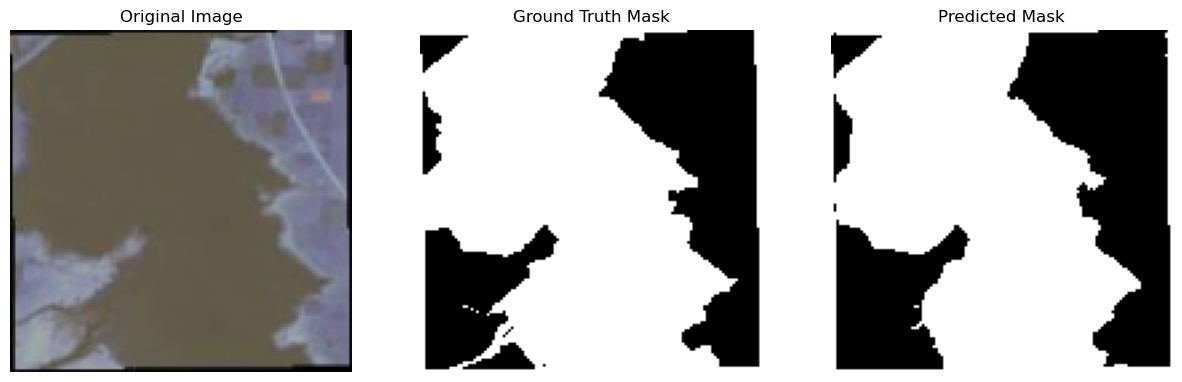

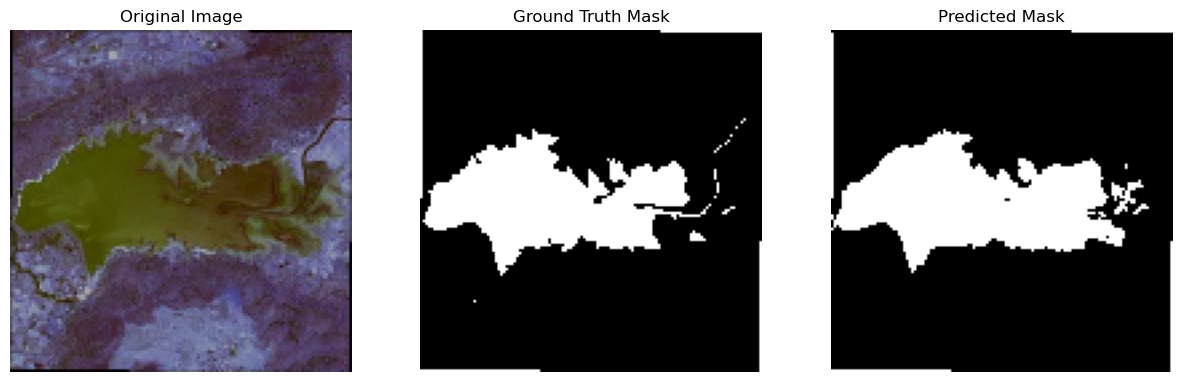

In [17]:
# Select 5 random indices
random_indices = random.sample(range(len(X_val)), 5)

# Plot random predictions alongside original images and ground truth masks
for i, idx in enumerate(random_indices):
    plt.figure(figsize=(15, 5))

    # Original validation image
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[idx])
    plt.title("Original Image")
    plt.axis('off')

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(y_val[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_masks[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()


### There were some images, whose masks were completely blacked out, which we deleted.

In [5]:
import numpy as np
import os
import cv2
mask_folder = "D:/Water Bodies Dataset/Masks/"
mask_files = sorted(os.listdir(mask_folder))
white_mask_count = 0

for mask_file in mask_files:
    mask = cv2.imread(os.path.join(mask_folder, mask_file), cv2.IMREAD_GRAYSCALE)
    if np.all(mask == 255):  # Check if the entire mask is white
        print(f"Completely white mask: {mask_file}")
        white_mask_count += 1

print(f"Total completely white masks: {white_mask_count}")


Completely white mask: water_body_1023.jpg
Completely white mask: water_body_1061.jpg
Completely white mask: water_body_1225.jpg
Completely white mask: water_body_1226.jpg
Completely white mask: water_body_1232.jpg
Completely white mask: water_body_1244.jpg
Completely white mask: water_body_1333.jpg
Completely white mask: water_body_1342.jpg
Completely white mask: water_body_1364.jpg
Completely white mask: water_body_1370.jpg
Completely white mask: water_body_1371.jpg
Completely white mask: water_body_1397.jpg
Completely white mask: water_body_15.jpg
Completely white mask: water_body_1552.jpg
Completely white mask: water_body_1553.jpg
Completely white mask: water_body_1562.jpg
Completely white mask: water_body_1606.jpg
Completely white mask: water_body_1607.jpg
Completely white mask: water_body_1616.jpg
Completely white mask: water_body_1619.jpg
Completely white mask: water_body_1621.jpg
Completely white mask: water_body_1659.jpg
Completely white mask: water_body_1661.jpg
Completely wh

In [6]:
import os
import cv2
import numpy as np

# Define the paths for images and masks
image_folder = "D:/Water Bodies Dataset/Images/"
mask_folder = "D:/Water Bodies Dataset/Masks/"

# Get all mask files (assuming masks are in .jpg format)
mask_files = sorted(os.listdir(mask_folder))

# Initialize counter for white masks
white_mask_count = 0

# Loop through all mask files
for mask_file in mask_files:
    mask_path = os.path.join(mask_folder, mask_file)
    
    # Load the mask as a grayscale image
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Check if the mask is completely white
    if mask is not None and np.all(mask == 255):
        print(f"Completely white mask: {mask_file}")
        white_mask_count += 1
        
        # Construct the corresponding image file path
        image_file = mask_file.replace('.jpg', '.jpg')  # Assuming images are in .jpg format
        image_path = os.path.join(image_folder, image_file)
        
        # Delete both the image and mask if both exist
        if os.path.exists(image_path):
            os.remove(image_path)
            print(f"Deleted image: {image_file}")
        
        os.remove(mask_path)
        print(f"Deleted mask: {mask_file}")

# Print the total number of white masks
print(f"Total completely white masks deleted: {white_mask_count}")


Completely white mask: water_body_1023.jpg
Deleted image: water_body_1023.jpg
Deleted mask: water_body_1023.jpg
Completely white mask: water_body_1061.jpg
Deleted image: water_body_1061.jpg
Deleted mask: water_body_1061.jpg
Completely white mask: water_body_1225.jpg
Deleted image: water_body_1225.jpg
Deleted mask: water_body_1225.jpg
Completely white mask: water_body_1226.jpg
Deleted image: water_body_1226.jpg
Deleted mask: water_body_1226.jpg
Completely white mask: water_body_1232.jpg
Deleted image: water_body_1232.jpg
Deleted mask: water_body_1232.jpg
Completely white mask: water_body_1244.jpg
Deleted image: water_body_1244.jpg
Deleted mask: water_body_1244.jpg
Completely white mask: water_body_1333.jpg
Deleted image: water_body_1333.jpg
Deleted mask: water_body_1333.jpg
Completely white mask: water_body_1342.jpg
Deleted image: water_body_1342.jpg
Deleted mask: water_body_1342.jpg
Completely white mask: water_body_1364.jpg
Deleted image: water_body_1364.jpg
Deleted mask: water_body_1